<a href="https://colab.research.google.com/github/Prashant230531/AI_FinalYear/blob/main/WORKSHOP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop 6
Name: Prashant Sharma
Student ID: [2417736]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing Required Libraries


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import random
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(123)
tf.random.set_seed(123)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check GPU availability
print(f"\nGPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
Keras version: 3.13.2

GPU Available: []


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

TASK 1


In [ ]:
# Define the path to your dataset in Google Drive
base_dir = '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Verify paths exist
print("Checking dataset paths...")
print(f"Base directory exists: {os.path.exists(base_dir)}")
print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Test directory exists: {os.path.exists(test_dir)}")

if not os.path.exists(train_dir):
    print("\n⚠ ERROR: Train directory not found!")
    print(f"Expected path: {train_dir}")
    print("\nPlease verify your Google Drive folder structure.")
else:
    print("\n✓ All paths verified successfully!")

Checking dataset paths...
Base directory exists: True
Train directory exists: True
Test directory exists: True

✓ All paths verified successfully!


In [ ]:
base_dir = '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon'

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2

LOAD DATASET

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Found 120 files belonging to 2 classes.
Using 96 files for training.
Found 120 files belonging to 2 classes.
Using 24 files for validation.
Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.6250 - loss: 3.6719 - val_accuracy: 0.9167 - val_loss: 0.2900
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5104 - loss: 8.7185 - val_accuracy: 0.9167 - val_loss: 0.3039
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.7396 - loss: 5.1396 - val_accuracy: 0.7500 - val_loss: 0.3982
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.6771 - loss: 5.0358 - val_accuracy: 0.1250 - val_loss: 1.3585
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5938 - loss: 4.1516 - val_accuracy: 0.4167 - val_loss: 1.0997
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7396 - loss: 2.2036 - val_accuracy: 0.4167 - val_loss: 2.5995
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6667 - loss: 2.8007 - val_accuracy: 0.2917 - val_loss: 4.

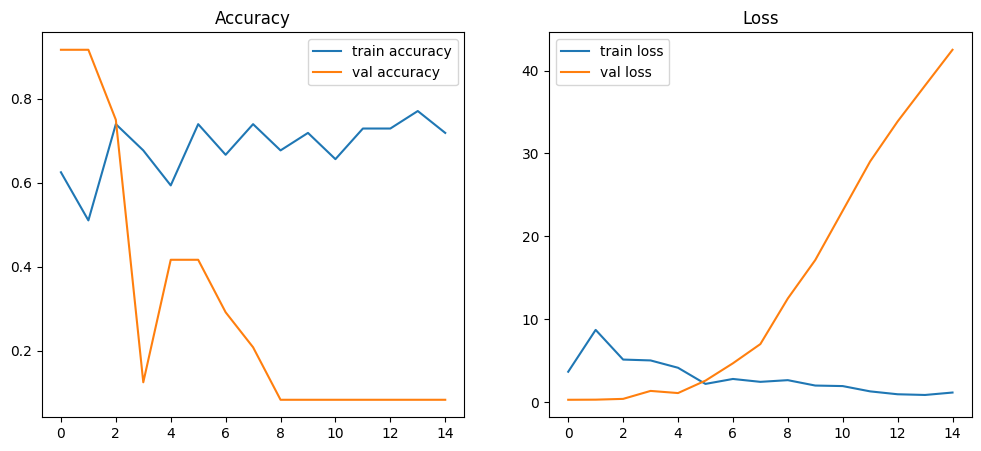

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 📁 Dataset path
train_dir = '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon'

# 📏 Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# 🔹 Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# 🔹 Rescaling
rescale = layers.Rescaling(1./255)

# 📂 Load dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

#  Class info
class_names = train_ds.class_names
num_classes = len(class_names)

#  Apply preprocessing
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

#  Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

#  Improved CNN Model
model = models.Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),

    # Data Augmentation
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    #  Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    #  Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

#  Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

# Plot Accuracy & Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")

plt.show()

TASK2

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

In [ ]:
train_dir = '/content/drive/MyDrive/AI/FruitinAmazon/FruitinAmazon/train'

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [ ]:
rescale = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dense(num_classes, activation='softmax')(x)

In [ ]:
model = models.Model(inputs=base_model.input, outputs=x)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 66s 21s/step - accuracy: 0.1528 - loss: 1.8583 - val_accuracy: 0.2778 - val_loss: 1.8792
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 25s/step - accuracy: 0.3750 - loss: 1.5592 - val_accuracy: 0.4444 - val_loss: 1.5500
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 69s 23s/step - accuracy: 0.6528 - loss: 1.3235 - val_accuracy: 0.5000 - val_loss: 1.4985
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 71s 23s/step - accuracy: 0.6528 - loss: 1.1659 - val_accuracy: 0.5000 - val_loss: 1.5742
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 72s 25s/step - accuracy: 0.6528 - loss: 1.0337 - val_accuracy: 0.5000 - val_loss: 1.5476
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 20s/step - accuracy: 0.7083 - loss: 0.9144 - val_accuracy: 0.5556 - val_loss: 1.3313
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 21s/step - accuracy: 0.8333 - loss: 0.7951 - val_accuracy: 0.5556 - val_loss: 1.2501
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 63s 21s/step - accuracy: 0.8333 - loss: 0.7364 - val_accuracy: 0.5556 - val_loss: 1.2267


In [ ]:
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Show some predictions
for i in range(10):
    print(f"Actual: {class_names[y_true[i]]} | Predicted: {class_names[y_pred[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Actual: tucuma | Predicted: tucuma
Actual: guarana | Predicted: guarana
Actual: graviola | Predicted: guarana
Actual: tucuma | Predicted: acai
Actual: pupunha | Predicted: acai
Actual: guarana | Predicted: acai
Actual: acai | Predicted: cupuacu
Actual: pupunha | Predicted: graviola
Actual: pupunha | Predicted: cupuacu
Actual: guarana | Predicted: acai


In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.40      0.67      0.50         3
     guarana       0.33      0.20      0.25         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.33      0.33      0.33         3

    accuracy                           0.22        18
   macro avg       0.18      0.20      0.18        18
weighted avg       0.21      0.22      0.21        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
